In [1]:
from sklearn.datasets import load_iris    
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [8]:
model=KNeighborsClassifier(n_neighbors=50)
iris=load_iris()
X=iris.data
y=iris.target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
model.fit(X_train_scaled,y_train)
accuracy=model.score(X_test_scaled,y_test)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.93


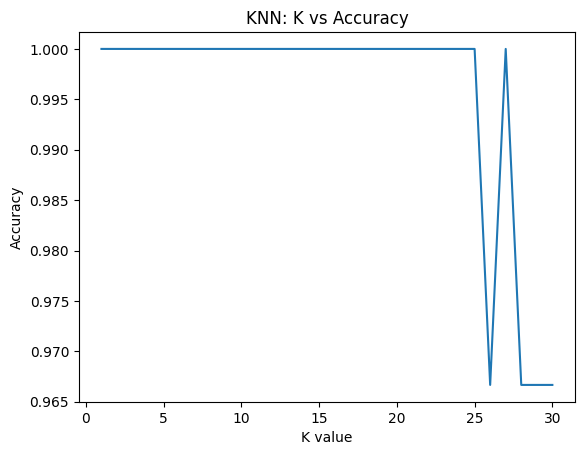

In [9]:
k_values = range(1, 31)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    accuracies.append(model.score(X_test_scaled, y_test))

import matplotlib.pyplot as plt
plt.plot(k_values, accuracies)
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("KNN: K vs Accuracy")
plt.show()

In [12]:

from sklearn.model_selection import GridSearchCV
param_grid = {'n_neighbors': range(1, 20)}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)
print(f"Best K: {grid_search.best_params_['n_neighbors']}")
print(f"Best Accuracy: {grid_search.best_score_:.2f}")

Best K: 3
Best Accuracy: 0.95
